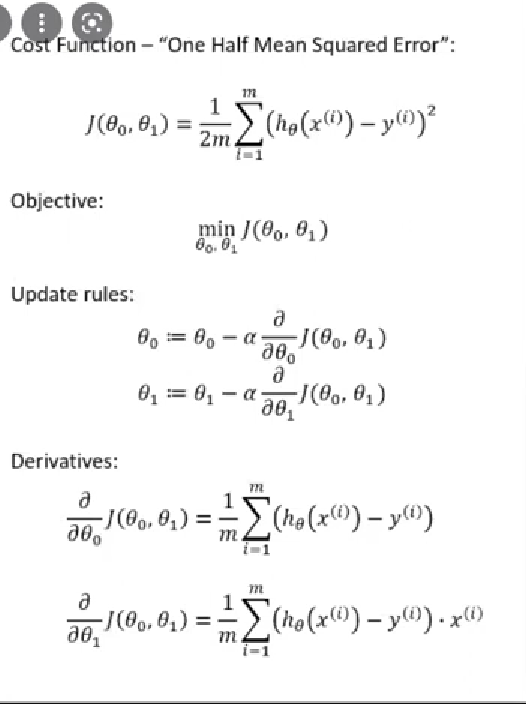

In [ ]:
def gradient_decent(x,y,m_current=0,b_current=0,iter=1000,LR=0.08,b_history=[],m_history=[]):
  y_pred=m_current*x+b_current
  n=len(x)
  frac=1/(2*n)
  for i in range(iter):
    y_pred = m_current * x + b_current
    cost=frac*sum([val**2 for val in(y-y_pred) ])
    md = -(1/n) * sum(x * (y - y_pred))
    bd = -(1/n) * sum(y - y_pred)
    m_current=m_current-LR*md
    b_current=b_current-LR*bd
    m_history.append(m_current)
    b_history.append(b_current)
    print("b {}  m {}   cost {} i {}".format(b_current,m_current,cost,i))
  plt.plot(m_history, label="m")
  plt.plot(b_history, label="b")

In [ ]:

x = np.array([1,2,3,4,5])
y = np.array([5,7,9,11,13])

b 0.72  m 2.48   cost 44.5 i 0
b 0.7871999999999999  m 2.6048   cost 0.5832 i 1
b 0.8190719999999999  m 2.6036479999999997   cost 0.44514432000000026 i 2
b 0.84867072  m 2.59586048   cost 0.43283498803200005 i 3
b 0.8777705472  m 2.5878222848   cost 0.42120595717816284 i 4
b 0.906471555072  m 2.579873742848   cost 0.4098903395128522 i 5
b 0.93478413238272  m 2.57203167592448   cost 0.39887871654888457 i 6
b 0.9627137995702272  m 2.5642956093390845   cost 0.38816291866760344 i 7
b 0.9902657493632288  m 2.5566641612238357   cost 0.3777349985784373 i 8
b 1.01744509072045  m 2.5491359194996854   cost 0.36758722250137654 i 9
b 1.0442568627828894  m 2.5417094885670544   cost 0.3577120644229065 i 10
b 1.0707060365041652  m 2.534383491560153   cost 0.3481022005143785 i 11
b 1.0967975156093952  m 2.527156570226219   cost 0.3387505037003526 i 12
b 1.122536137506351  m 2.5200273846808914   cost 0.3296500383728622 i 13
b 1.147926674182429  m 2.5129946131601826   cost 0.3207940552476775 i 14
b 1.17

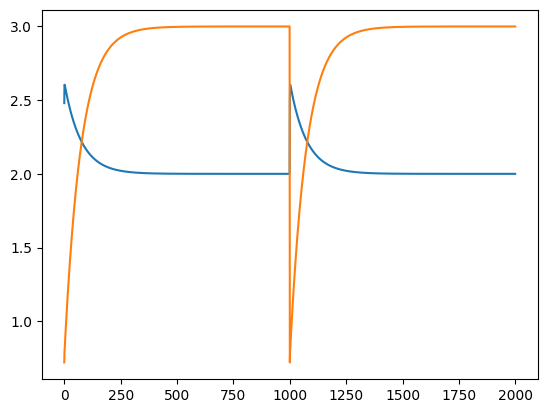

In [ ]:
gradient_decent(x,y)

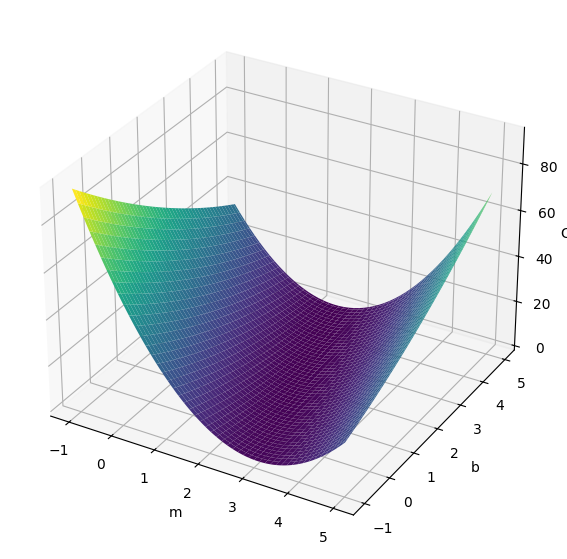

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

# البيانات
x = np.array([1,2,3,4,5])
y = np.array([5,7,9,11,13])

# قيم m و b
m_vals = np.linspace(-1, 5, 100)
b_vals = np.linspace(-1, 5, 100)

# شبكة
M, B = np.meshgrid(m_vals, b_vals)

# مصفوفة cost
J = np.zeros(M.shape)

# حساب cost لكل نقطة
for i in range(M.shape[0]):
    for j in range(M.shape[1]):

        y_pred = M[i,j] * x + B[i,j]

        J[i,j] = (1/(2*len(x))) * np.sum((y-y_pred)**2)

# الرسم
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    M,
    B,
    J,
    cmap='viridis'
)

ax.set_xlabel("m")
ax.set_ylabel("b")
ax.set_zlabel("Cost")

plt.show()

# New Section
Multi classification

In [ ]:
import pandas as pd



In [ ]:
data=pd.read_excel("/content/50_StartUp.xlsx")

In [ ]:
data

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [ ]:
data.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [ ]:
data.isna().sum()

,0
R&D Spend,0
Administration,0
Marketing Spend,0
State,0
Profit,0


In [ ]:
corr = data.corr(numeric_only=True)
corr

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: >

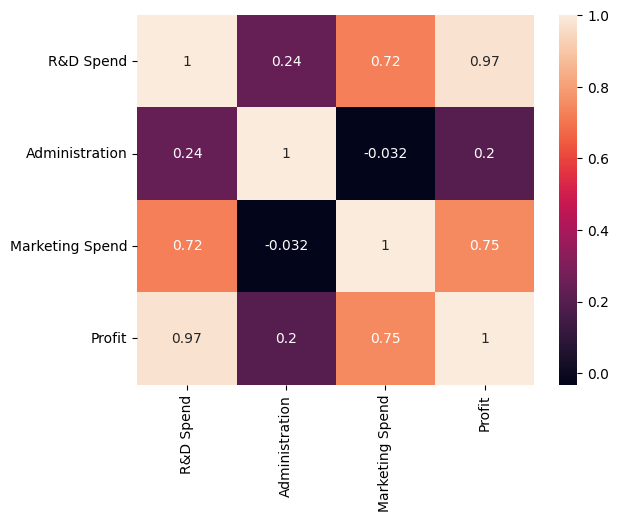

In [ ]:
import seaborn as sns
sns.heatmap(corr,annot=True)

<Axes: xlabel='Marketing Spend', ylabel='Profit'>

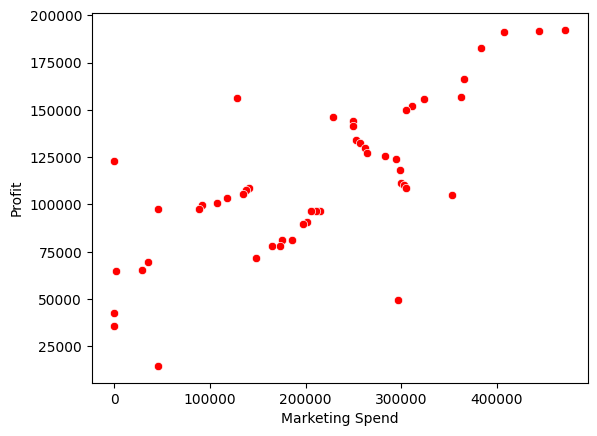

In [ ]:

sns.scatterplot(x="Marketing Spend",y="Profit",data=data,color="red")

array([[<Axes: title={'center': 'R&D Spend'}>,
        <Axes: title={'center': 'Administration'}>],
       [<Axes: title={'center': 'Marketing Spend'}>,
        <Axes: title={'center': 'Profit'}>]], dtype=object)

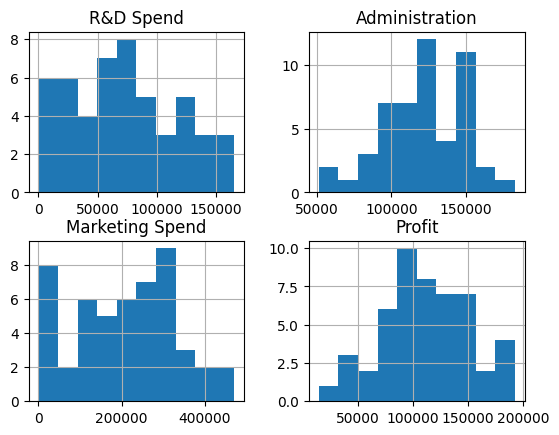

In [ ]:
data.hist()

In [ ]:
pd

In [ ]:
data2=pd.read_excel("/content/50_StartUp.xlsx")

In [ ]:
data2["State"].unique()

array(['New York', 'California', 'Florida'], dtype=object)

In [ ]:
dfState=pd.get_dummies(data2["State"])

In [ ]:
dfState

,California,Florida,New York
0,False,False,True
1,True,False,False
2,False,True,False
3,False,False,True
4,False,True,False
5,False,False,True
6,True,False,False
7,False,True,False
8,False,False,True
9,True,False,False


In [ ]:
full=pd.concat([data,dfState],axis=1)

In [ ]:

full=full.drop(["Florida"],axis=1)
full

,R&D Spend,Administration,Marketing Spend,State,Profit,California,New York
0,165349.20,136897.80,471784.10,New York,192261.83,False,True
1,162597.70,151377.59,443898.53,California,191792.06,True,False
2,153441.51,101145.55,407934.54,Florida,191050.39,False,False
3,144372.41,118671.85,383199.62,New York,182901.99,False,True
4,142107.34,91391.77,366168.42,Florida,166187.94,False,False
5,131876.90,99814.71,362861.36,New York,156991.12,False,True
6,134615.46,147198.87,127716.82,California,156122.51,True,False
7,130298.13,145530.06,323876.68,Florida,155752.60,False,False
8,120542.52,148718.95,311613.29,New York,152211.77,False,True
9,123334.88,108679.17,304981.62,California,149759.96,True,False


In [ ]:
x=full.drop(["Profit","State"],axis=1)
y=full["Profit"]

In [ ]:
y

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94
5,156991.12
6,156122.51
7,155752.60
8,152211.77
9,149759.96


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7)

In [ ]:
x_train.count()

,0
R&D Spend,35
Administration,35
Marketing Spend,35
California,35
New York,35


In [ ]:
x_test.count()

,0
R&D Spend,15
Administration,15
Marketing Spend,15
California,15
New York,15


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
myModel=LinearRegression()

In [ ]:
print(type(myModel))

<class 'sklearn.linear_model._base.LinearRegression'>


In [ ]:
finalModel=myModel.fit(x_train,y_train)

In [ ]:
y_pred=finalModel.predict(x_test)
y_pred

array([ 57758.57591016,  86858.25734194,  98627.49627106, 129881.42780084,
       160765.69046798,  96436.13125681,  72515.57526367, 113020.08838181,
       160227.05789427, 152372.4802867 , 128605.74343979,  72421.94063423,
        62231.62919539,  72579.47649086,  89173.12754213])

In [ ]:
x_test

,R&D Spend,Administration,Marketing Spend,California,New York
43,15505.73,127382.30,35534.17,False,True
34,46426.07,157693.92,210797.67,True,False
32,63408.86,129219.61,46085.25,True,False
17,94657.16,145077.58,282574.31,False,True
7,130298.13,145530.06,323876.68,False,False
33,55493.95,103057.49,214634.81,False,False
40,28754.33,118546.05,172795.67,True,False
27,72107.60,127864.55,353183.81,False,True
6,134615.46,147198.87,127716.82,True,False
8,120542.52,148718.95,311613.29,False,True


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
temp=pd.DataFrame({"y_test":y_test,"y_p":y_pred,"y_test-y_p":y_test-y_pred})

In [ ]:
temp

,y_test,y_p,y_test-y_p
43,69758.98,57758.575910,12000.404090
34,96712.80,86858.257342,9854.542658
32,97427.84,98627.496271,-1199.656271
17,125370.37,129881.427801,-4511.057801
7,155752.60,160765.690468,-5013.090468
33,96778.92,96436.131257,342.788743
40,78239.91,72515.575264,5724.334736
27,105008.31,113020.088382,-8011.778382
6,156122.51,160227.057894,-4104.547894
8,152211.77,152372.480287,-160.710287


In [ ]:
from sklearn.metrics import mean_absolute_error


In [ ]:
mse=mean_absolute_error(y_test,y_pred)

In [ ]:
mse

5936.162727151034

In [ ]:
rmse=np.sqrt(mse)

In [ ]:
rmse

np.float64(77.04649717638716)

In [ ]:
t=data.drop(["State"],axis=1)

In [ ]:
t

,R&D Spend,Administration,Marketing Spend,Profit
0,165349.20,136897.80,471784.10,192261.83
1,162597.70,151377.59,443898.53,191792.06
2,153441.51,101145.55,407934.54,191050.39
3,144372.41,118671.85,383199.62,182901.99
4,142107.34,91391.77,366168.42,166187.94
5,131876.90,99814.71,362861.36,156991.12
6,134615.46,147198.87,127716.82,156122.51
7,130298.13,145530.06,323876.68,155752.60
8,120542.52,148718.95,311613.29,152211.77
9,123334.88,108679.17,304981.62,149759.96


<Axes: >

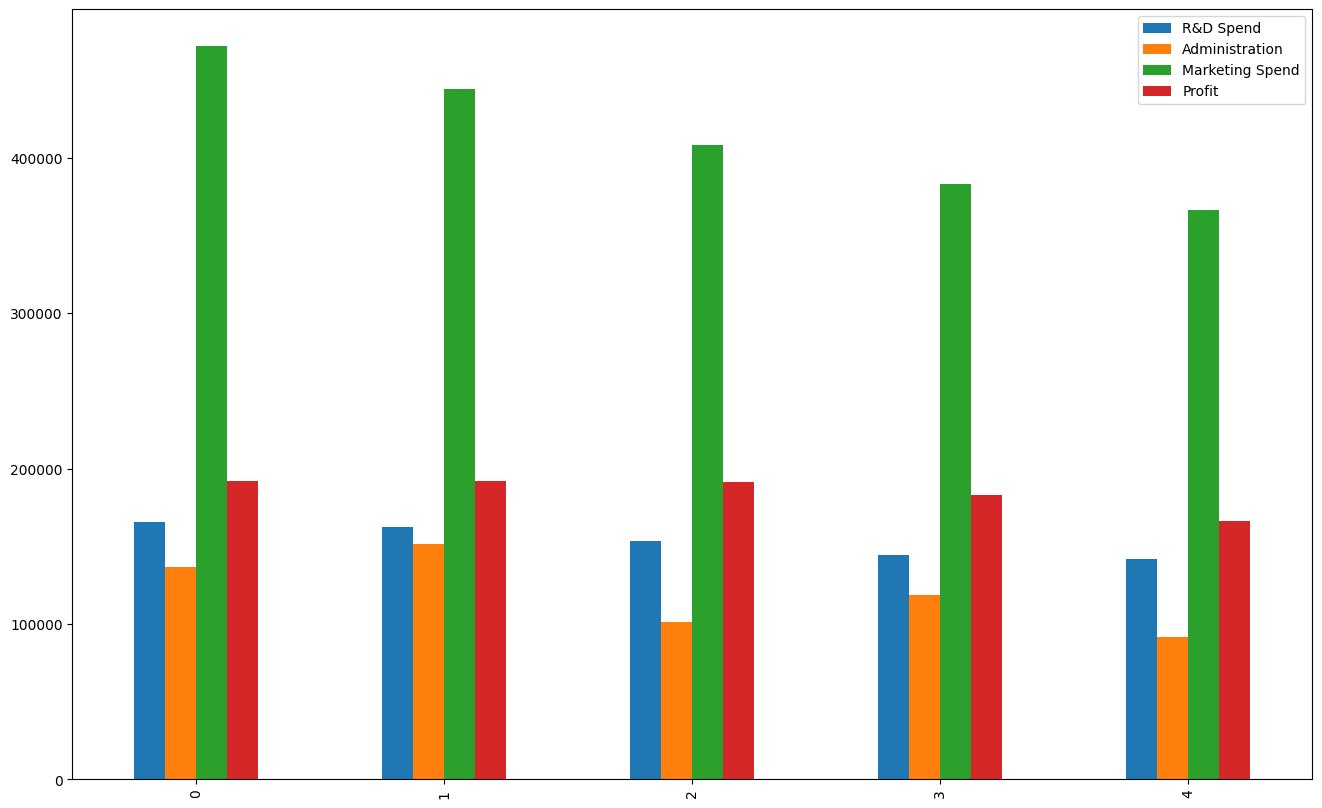

In [ ]:
t.head().plot(kind="bar",figsize=(16,10))

In [ ]:
import pandas as pd

data = pd.DataFrame({

    "YearsExperience":[
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10
    ],

    "Salary":[
        30000,
        35000,
        40000,
        50000,
        55000,
        65000,
        70000,
        80000,
        85000,
        95000
    ]

})

In [ ]:
import statsmodels.api as sm
x = data[["YearsExperience"]]
y = data["Salary"]
stmodel=sm.OLS(y,x).fit()
stmodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Salary   R-squared (uncentered):                   0.978
Model:                            OLS   Adj. R-squared (uncentered):              0.975
Method:                 Least Squares   F-statistic:                              397.5
Date:                Mon, 11 May 2026   Prob (F-statistic):                    9.34e-09
Time:                        17:09:18   Log-Likelihood:                         -105.81
No. Observations:                  10   AIC:                                      213.6
Df Residuals:                       9   BIC:                                      213.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
YearsExperience  1.021e+04    512.013     19.937      0.000    9049.537    1.14e+04
==============================================================================
Omnibus:                        0.484   Durbin-Watson:                   0.149
Prob(Omnibus):                  0.785   Jarque-Bera (JB):                0.524
Skew:                           0.273   Prob(JB):                        0.770
Kurtosis:                       2.020   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""